In [1]:
# Install dependencies (uncomment if needed)
# %pip install pandas pyarrow beautifulsoup4 lxml matplotlib seaborn wordcloud -q

import pandas as pd
import numpy as np
import re
import os
import time
from bs4 import BeautifulSoup
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print(' Libraries imported!')

 Libraries imported!


In [2]:
#  UPDATE THIS PATH to where your parquet files are stored
DATA_DIR = 'C:/Users/satya/Desktop/Cleaned_Dataset'  # Change to your path, e.g., './data/raw' or '/content/drive/MyDrive/stackoverflow-recsys/data/raw'

# Load raw data
print(' Loading raw parquet files...')

start = time.time()
questions_raw = pd.read_parquet(os.path.join(DATA_DIR, 'questions_500k.parquet'))
print(f'   Questions loaded: {len(questions_raw):,} rows ({time.time()-start:.1f}s)')

start = time.time()
answers_raw = pd.read_parquet(os.path.join(DATA_DIR, 'answers_top3.parquet'))
print(f'   Answers loaded:   {len(answers_raw):,} rows ({time.time()-start:.1f}s)')

tags_df = pd.read_parquet(os.path.join(DATA_DIR, 'top_tags.parquet'))
print(f'   Tags loaded:      {len(tags_df):,} rows')

print(f'\n Questions columns: {list(questions_raw.columns)}')
print(f' Answers columns:   {list(answers_raw.columns)}')

 Loading raw parquet files...
   Questions loaded: 500,000 rows (2.7s)
   Answers loaded:   1,230,649 rows (3.5s)
   Tags loaded:      30 rows

 Questions columns: ['id', 'title', 'body', 'tags', 'score', 'view_count', 'answer_count', 'accepted_answer_id', 'creation_date', 'primary_tag']
 Answers columns:   ['id', 'parent_id', 'body', 'score', 'creation_date', 'answer_rank', 'is_accepted']


In [3]:
# Quick look at raw data BEFORE cleaning
print(' Raw Question Sample (BEFORE cleaning):')
print('=' * 80)
sample = questions_raw.iloc[0]
print(f"Title: {sample['title'][:80]}")
print(f"Tags:  {sample['tags']}")
print(f"Score: {sample['score']}")
print(f"\nBody (first 500 chars — notice the HTML):")
print(sample['body'][:500])
print('\n' + '=' * 80)

 Raw Question Sample (BEFORE cleaning):
Title: Difference between decimal, float and double in .NET?
Tags:  .net|floating-point|double|decimal
Score: 2345

Body (first 500 chars — notice the HTML):
<p>What is the difference between <code>decimal</code>, <code>float</code> and <code>double</code> in .NET?</p>

<p>When would someone use one of these?</p>



In [4]:
# Check for nulls, duplicates, and data types
print(' QUESTIONS — Pre-Cleaning Report')
print('=' * 50)
print(f'  Total rows:       {len(questions_raw):,}')
print(f'  Duplicate IDs:    {questions_raw["id"].duplicated().sum():,}')
print(f'\n  Null values:')
for col in questions_raw.columns:
    nulls = questions_raw[col].isna().sum()
    if nulls > 0:
        print(f'    {col:<25s}: {nulls:>8,} ({nulls/len(questions_raw)*100:.2f}%)')
    else:
        print(f'    {col:<25s}: {nulls:>8,} ')

print(f'\n\n ANSWERS — Pre-Cleaning Report')
print('=' * 50)
print(f'  Total rows:       {len(answers_raw):,}')
print(f'  Duplicate IDs:    {answers_raw["id"].duplicated().sum():,}')
print(f'  Negative scores:  {(answers_raw["score"] < 0).sum():,}')
print(f'\n  Null values:')
for col in answers_raw.columns:
    nulls = answers_raw[col].isna().sum()
    if nulls > 0:
        print(f'    {col:<25s}: {nulls:>8,} ({nulls/len(answers_raw)*100:.2f}%)')
    else:
        print(f'    {col:<25s}: {nulls:>8,} ')

 QUESTIONS — Pre-Cleaning Report
  Total rows:       500,000
  Duplicate IDs:    0

  Null values:
    id                       :        0 
    title                    :        0 
    body                     :        0 
    tags                     :        0 
    score                    :        0 
    view_count               :        0 
    answer_count             :        0 
    accepted_answer_id       :  105,520 (21.10%)
    creation_date            :        0 
    primary_tag              :        0 


 ANSWERS — Pre-Cleaning Report
  Total rows:       1,230,649
  Duplicate IDs:    0
  Negative scores:  12,632

  Null values:
    id                       :        0 
    parent_id                :        0 
    body                     :        0 
    score                    :        0 
    creation_date            :        0 
    answer_rank              :        0 
    is_accepted              :        0 


In [5]:
def clean_html_body(html_text):
    """
    Single-pass HTML cleaning that returns BOTH clean text and code blocks.
    
    Parses HTML only ONCE (not twice), which halves processing time.
    
    Returns:
        tuple: (clean_text, code_blocks_text)
        
    Rules:
        - <pre><code>...</code></pre>  → REMOVED from text, stored in code_blocks
        - <code>word</code>            → 'word' KEPT in text (inline code)
        - All other HTML tags          → stripped, text kept
        - URLs                         → removed
        - Whitespace                   → normalized
    """
    if pd.isna(html_text) or not html_text:
        return '', ''
    
    soup = BeautifulSoup(html_text, 'lxml')
    
    # Step 1: Extract and REMOVE <pre> blocks (multi-line code)
    code_blocks = []
    for pre in soup.find_all('pre'):
        code_text = pre.get_text()
        if code_text.strip():
            code_blocks.append(code_text.strip())
        pre.decompose()  # Remove from soup
    
    # Step 2: KEEP text inside inline <code> tags
    # Replace <code>word</code> with just 'word'
    for code in soup.find_all('code'):
        code.replace_with(code.get_text())
    
    # Step 3: Get all remaining text
    text = soup.get_text(separator=' ')
    
    # Step 4: Remove URLs
    text = re.sub(r'https?://\\S+', '', text)
    
    # Step 5: Normalize whitespace
    text = re.sub(r'\\s+', ' ', text).strip()
    
    # Combine code blocks
    code_blocks_str = '\n---\n'.join(code_blocks) if code_blocks else ''
    
    return text, code_blocks_str


def clean_tags(tags_str):
    """
    Clean tags from pipe-separated to comma-separated.
    'python|pandas|dataframe' → 'python,pandas,dataframe'
    Also handles the <tag> format if present.
    """
    if pd.isna(tags_str) or not tags_str:
        return ''
    
    # Remove < > if present (some formats use <python><pandas>)
    tags_str = tags_str.replace('<', '').replace('>', '|')
    
    # Split by pipe, clean, rejoin with comma
    tags = [t.strip() for t in tags_str.split('|') if t.strip()]
    return ','.join(tags)


# ============================================================
# TEST: Verify cleaning handles all cases correctly
# ============================================================

print(' Testing cleaning functions:')
print('=' * 80)

# Test 1: Inline code words should be KEPT
test1 = '<p>What is the difference between <code>decimal</code>, <code>float</code> and <code>double</code> in .NET?</p>'
text1, code1 = clean_html_body(test1)
print(f'\nTest 1 — Inline code (should KEEP words):')
print(f'  Input:  ...between <code>decimal</code>, <code>float</code>...')
print(f'  Output: {text1}')
assert 'decimal' in text1 and 'float' in text1 and 'double' in text1, 'FAIL: inline code words lost!'
print(f'   PASS — decimal, float, double preserved')

# Test 2: Code blocks should be REMOVED from text, stored separately
test2 = '<p>How to sort a list:</p><pre><code>sorted_list = sorted(my_list)</code></pre><p>This returns a new list.</p>'
text2, code2 = clean_html_body(test2)
print(f'\nTest 2 — Code block (should REMOVE from text, STORE separately):')
print(f'  Clean text:  {text2}')
print(f'  Code blocks: {code2}')
assert 'sorted_list' not in text2, 'FAIL: code block leaked into text!'
assert 'sorted_list' in code2, 'FAIL: code block not captured!'
print(f'   PASS — code removed from text, stored in code_blocks')

# Test 3: Mixed — inline code + code block together
test3 = '<p>Use <code>pandas</code> to read a <code>CSV</code>:</p><pre><code>import pandas as pd\ndf = pd.read_csv("data.csv")</code></pre><p>The <code>read_csv</code> function is flexible.</p>'
text3, code3 = clean_html_body(test3)
print(f'\nTest 3 — Mixed (inline code + code block):')
print(f'  Clean text:  {text3}')
print(f'  Code blocks: {code3[:60]}...')
assert 'pandas' in text3 and 'CSV' in text3 and 'read_csv' in text3, 'FAIL: inline words lost!'
assert 'import pandas' not in text3, 'FAIL: code block leaked into text!'
print(f'   PASS — inline words kept, code block separated')

# Test 4: Tags cleaning
test_tags = '.net|floating-point|double|decimal'
result_tags = clean_tags(test_tags)
print(f'\nTest 4 — Tags:')
print(f'  \"{test_tags}\" → \"{result_tags}\"')
assert result_tags == '.net,floating-point,double,decimal', 'FAIL!'
print(f'   PASS')

# Test 5: Real sample from our data
print(f'\nTest 5 — Real sample from dataset:')
sample_html = questions_raw.iloc[0]['body']
sample_text, sample_code = clean_html_body(sample_html)
print(f'  Clean text (first 200 chars): {sample_text[:200]}')
print(f'  Code blocks: {"Yes (" + str(len(sample_code)) + " chars)" if sample_code else "None"}')

print('\n' + '=' * 80)
print(' All tests passed!')

 Testing cleaning functions:

Test 1 — Inline code (should KEEP words):
  Input:  ...between <code>decimal</code>, <code>float</code>...
  Output: What is the difference between  decimal ,  float  and  double  in .NET?
   PASS — decimal, float, double preserved

Test 2 — Code block (should REMOVE from text, STORE separately):
  Clean text:  How to sort a list: This returns a new list.
  Code blocks: sorted_list = sorted(my_list)
   PASS — code removed from text, stored in code_blocks

Test 3 — Mixed (inline code + code block):
  Clean text:  Use  pandas  to read a  CSV : The  read_csv  function is flexible.
  Code blocks: import pandas as pd
df = pd.read_csv("data.csv")...
   PASS — inline words kept, code block separated

Test 4 — Tags:
  ".net|floating-point|double|decimal" → ".net,floating-point,double,decimal"
   PASS

Test 5 — Real sample from dataset:
  Clean text (first 200 chars): What is the difference between  decimal ,  float  and  double  in .NET? 
 When would someone use o

In [6]:
# ============================================================
# STEP 4.1: Apply cleaning to all 500K questions
# ============================================================
# Uses single-pass cleaning (parses HTML once per question, not twice)
# Estimated time: ~10-15 minutes on a modern laptop

print('⏳ Cleaning 500K question bodies...')
print('   Single-pass: HTML → plain text + code extraction simultaneously')
print('   Progress updates every 50K questions\n')

start = time.time()

body_clean_list = []
code_blocks_list = []
total = len(questions_raw)

for i, html in enumerate(questions_raw['body']):
    text, code = clean_html_body(html)
    body_clean_list.append(text)
    code_blocks_list.append(code)
    
    # Progress update every 50K rows
    if (i + 1) % 50000 == 0:
        elapsed = time.time() - start
        rate = (i + 1) / elapsed
        remaining = (total - i - 1) / rate
        print(f'   {i+1:>7,} / {total:,} ({(i+1)/total*100:.0f}%) '
              f'— {elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining')

questions_raw['body_clean'] = body_clean_list
questions_raw['code_blocks'] = code_blocks_list

elapsed = time.time() - start
print(f'\n   Body cleaning complete in {elapsed:.1f}s ({elapsed/60:.1f} min)')

# Clean tags
questions_raw['tags_clean'] = questions_raw['tags'].apply(clean_tags)
print(f'   Tags cleaned')

print(f'\n Question cleaning complete!')

⏳ Cleaning 500K question bodies...
   Single-pass: HTML → plain text + code extraction simultaneously
   Progress updates every 50K questions



    50,000 / 500,000 (10%) — 17s elapsed, ~152s remaining
   100,000 / 500,000 (20%) — 33s elapsed, ~133s remaining
   150,000 / 500,000 (30%) — 51s elapsed, ~119s remaining
   200,000 / 500,000 (40%) — 67s elapsed, ~101s remaining
   250,000 / 500,000 (50%) — 83s elapsed, ~83s remaining
   300,000 / 500,000 (60%) — 100s elapsed, ~66s remaining
   350,000 / 500,000 (70%) — 116s elapsed, ~50s remaining
   400,000 / 500,000 (80%) — 132s elapsed, ~33s remaining
   450,000 / 500,000 (90%) — 149s elapsed, ~17s remaining
   500,000 / 500,000 (100%) — 165s elapsed, ~0s remaining

   Body cleaning complete in 165.4s (2.8 min)
   Tags cleaned

 Question cleaning complete!


In [7]:
# ============================================================
# STEP 4.2: Add derived features for questions
# ============================================================

# Title length (characters)
questions_raw['title_length'] = questions_raw['title'].str.len()

# Clean body length (characters)
questions_raw['body_length'] = questions_raw['body_clean'].str.len()

# Word count of clean body
questions_raw['body_word_count'] = questions_raw['body_clean'].str.split().str.len().fillna(0).astype(int)

# Has code in the question?
questions_raw['has_code'] = (questions_raw['code_blocks'].str.len() > 0)

# Has accepted answer?
questions_raw['has_accepted_answer'] = questions_raw['accepted_answer_id'].notna()

# Number of tags (handle empty string edge case)
questions_raw['num_tags'] = questions_raw['tags_clean'].apply(
    lambda x: len(x.split(',')) if x else 0
)

# Tag list (as Python list — useful for analysis)
questions_raw['tags_list'] = questions_raw['tags_clean'].apply(
    lambda x: x.split(',') if x else []
)

print(' Derived features added:')
print(f'  title_length, body_length, body_word_count, has_code,')
print(f'  has_accepted_answer, num_tags, tags_list')

# Quick stats
print(f'\n Quick stats:')
print(f'  Avg title length:  {questions_raw["title_length"].mean():.0f} chars')
print(f'  Avg body length:   {questions_raw["body_length"].mean():.0f} chars')
print(f'  Avg word count:    {questions_raw["body_word_count"].mean():.0f} words')
print(f'  Has code:          {questions_raw["has_code"].mean()*100:.1f}%')
print(f'  Has accepted ans:  {questions_raw["has_accepted_answer"].mean()*100:.1f}%')
print(f'  Avg tags per q:    {questions_raw["num_tags"].mean():.1f}')

 Derived features added:
  title_length, body_length, body_word_count, has_code,
  has_accepted_answer, num_tags, tags_list

 Quick stats:
  Avg title length:  53 chars
  Avg body length:   542 chars
  Avg word count:    92 words
  Has code:          66.9%
  Has accepted ans:  78.9%
  Avg tags per q:    3.2


In [8]:
# ============================================================
# STEP 4.3: Handle edge cases and quality filters
# ============================================================

print(' Quality checks on cleaned questions:')

# Check for empty body after cleaning
empty_body = (questions_raw['body_clean'].str.len() == 0) | (questions_raw['body_clean'].isna())
print(f'  Empty body after cleaning: {empty_body.sum():,}')

# Check for very short bodies (< 20 characters after cleaning)
short_body = questions_raw['body_length'] < 20
print(f'  Very short body (< 20 chars): {short_body.sum():,}')

# Check for duplicate titles
dup_titles = questions_raw['title'].duplicated().sum()
print(f'  Duplicate titles: {dup_titles:,}')

# Remove questions with empty body after cleaning
before = len(questions_raw)
questions_raw = questions_raw[~empty_body].copy()
after = len(questions_raw)
print(f'\n  Removed {before - after:,} questions with empty body')
print(f'  Remaining: {len(questions_raw):,} questions')

 Quality checks on cleaned questions:
  Empty body after cleaning: 119
  Very short body (< 20 chars): 230
  Duplicate titles: 74

  Removed 119 questions with empty body
  Remaining: 499,881 questions


In [9]:
# ============================================================
# STEP 4.4: Select final columns and create clean dataframe
# ============================================================

questions_clean = questions_raw[[
    'id', 'title', 'body_clean', 'code_blocks', 'tags_clean',
    'primary_tag', 'score', 'view_count', 'answer_count',
    'has_accepted_answer', 'creation_date',
    'title_length', 'body_length', 'body_word_count',
    'has_code', 'num_tags'
]].copy()

# Rename for clarity
questions_clean = questions_clean.rename(columns={
    'body_clean': 'body',
    'tags_clean': 'tags'
})

# Sort by score descending
questions_clean = questions_clean.sort_values('score', ascending=False).reset_index(drop=True)

print(' Clean questions dataframe ready')
print(f'📋 Columns: {list(questions_clean.columns)}')
print(f'📊 Shape: {questions_clean.shape}')
print(f'\n📋 Sample row:')
sample = questions_clean.iloc[0]
for col in questions_clean.columns:
    val = sample[col]
    if isinstance(val, str) and len(val) > 100:
        val = val[:100] + '...'
    print(f'  {col:<25s}: {val}')

 Clean questions dataframe ready
📋 Columns: ['id', 'title', 'body', 'code_blocks', 'tags', 'primary_tag', 'score', 'view_count', 'answer_count', 'has_accepted_answer', 'creation_date', 'title_length', 'body_length', 'body_word_count', 'has_code', 'num_tags']
📊 Shape: (499881, 16)

📋 Sample row:
  id                       : 11227809
  title                    : Why is processing a sorted array faster than processing an unsorted array?
  body                     : Here is a piece of C++ code that shows some very peculiar behavior. For some strange reason, sorting...
  code_blocks              : #include <algorithm>
#include <ctime>
#include <iostream>

int main()
{
    // Generate data
    con...
  tags                     : java,c++,performance,cpu-architecture,branch-prediction
  primary_tag              : java
  score                    : 26621
  view_count               : 1746329
  answer_count             : 27
  has_accepted_answer      : True
  creation_date            : 2012-06-27

In [10]:
# ============================================================
# STEP 5.1: Filter out low-quality answers
# ============================================================

print(' Answer quality before filtering:')
print(f'  Total answers:           {len(answers_raw):,}')
print(f'  Negative score (< 0):    {(answers_raw["score"] < 0).sum():,}')
print(f'  Zero score:              {(answers_raw["score"] == 0).sum():,}')
print(f'  Positive score (> 0):    {(answers_raw["score"] > 0).sum():,}')

# Remove answers with negative scores
# These are answers the community voted DOWN — they shouldn't be recommended
before = len(answers_raw)
answers_raw = answers_raw[answers_raw['score'] >= 0].copy()
after = len(answers_raw)
print(f'\n  Removed {before - after:,} negative-score answers')
print(f'  Remaining: {len(answers_raw):,} answers')

 Answer quality before filtering:
  Total answers:           1,230,649
  Negative score (< 0):    12,632
  Zero score:              77,167
  Positive score (> 0):    1,140,850

  Removed 12,632 negative-score answers
  Remaining: 1,218,017 answers


In [11]:
# ============================================================
# STEP 5.2: Also remove answers whose question was removed in Step 4.3
# ============================================================

valid_question_ids = set(questions_clean['id'].tolist())
before = len(answers_raw)
answers_raw = answers_raw[answers_raw['parent_id'].isin(valid_question_ids)].copy()
after = len(answers_raw)
print(f'  Removed {before - after:,} orphaned answers (their question was removed)')
print(f'  Remaining: {len(answers_raw):,} answers')

  Removed 321 orphaned answers (their question was removed)
  Remaining: 1,217,696 answers


In [12]:
# ============================================================
# STEP 5.3: Clean answer bodies (single-pass with progress)
# ============================================================

print(f' Cleaning {len(answers_raw):,} answer bodies...')
print('   Single-pass: HTML → plain text + code extraction simultaneously')
print('   Progress updates every 100K answers\n')

start = time.time()

body_clean_list = []
code_blocks_list = []
total = len(answers_raw)

for i, html in enumerate(answers_raw['body']):
    text, code = clean_html_body(html)
    body_clean_list.append(text)
    code_blocks_list.append(code)
    
    if (i + 1) % 100000 == 0:
        elapsed = time.time() - start
        rate = (i + 1) / elapsed
        remaining = (total - i - 1) / rate
        print(f'   {i+1:>10,} / {total:,} ({(i+1)/total*100:.0f}%) '
              f'— {elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining')

answers_raw['body_clean'] = body_clean_list
answers_raw['code_blocks'] = code_blocks_list

elapsed = time.time() - start
print(f'\n   Answer cleaning complete in {elapsed:.1f}s ({elapsed/60:.1f} min)')

 Cleaning 1,217,696 answer bodies...
   Single-pass: HTML → plain text + code extraction simultaneously
   Progress updates every 100K answers

      100,000 / 1,217,696 (8%) — 30s elapsed, ~337s remaining
      200,000 / 1,217,696 (16%) — 61s elapsed, ~309s remaining
      300,000 / 1,217,696 (25%) — 95s elapsed, ~290s remaining
      400,000 / 1,217,696 (33%) — 130s elapsed, ~266s remaining
      500,000 / 1,217,696 (41%) — 164s elapsed, ~235s remaining
      600,000 / 1,217,696 (49%) — 197s elapsed, ~203s remaining
      700,000 / 1,217,696 (57%) — 228s elapsed, ~169s remaining
      800,000 / 1,217,696 (66%) — 260s elapsed, ~136s remaining
      900,000 / 1,217,696 (74%) — 291s elapsed, ~103s remaining
    1,000,000 / 1,217,696 (82%) — 325s elapsed, ~71s remaining
    1,100,000 / 1,217,696 (90%) — 360s elapsed, ~38s remaining
    1,200,000 / 1,217,696 (99%) — 389s elapsed, ~6s remaining

   Answer cleaning complete in 395.6s (6.6 min)


In [13]:
# ============================================================
# STEP 5.4: Add derived features for answers
# ============================================================

# Clean body length
answers_raw['body_length'] = answers_raw['body_clean'].str.len()

# Word count
answers_raw['body_word_count'] = answers_raw['body_clean'].str.split().str.len().fillna(0).astype(int)

# Has code?
answers_raw['has_code'] = (answers_raw['code_blocks'].str.len() > 0)

print(' Derived features added for answers')
print(f'  Avg body length:   {answers_raw["body_length"].mean():.0f} chars')
print(f'  Avg word count:    {answers_raw["body_word_count"].mean():.0f} words')
print(f'  Has code:          {answers_raw["has_code"].mean()*100:.1f}%')
print(f'  Is accepted:       {answers_raw["is_accepted"].mean()*100:.1f}%')

 Derived features added for answers
  Avg body length:   467 chars
  Avg word count:    77 words
  Has code:          66.9%
  Is accepted:       31.9%


In [14]:
# ============================================================
# STEP 5.5: Handle edge cases in answers
# ============================================================

# Remove answers with empty body after cleaning
empty_body = (answers_raw['body_clean'].str.len() == 0) | (answers_raw['body_clean'].isna())
print(f'  Empty answer body after cleaning: {empty_body.sum():,}')

before = len(answers_raw)
answers_raw = answers_raw[~empty_body].copy()
after = len(answers_raw)
print(f'  Removed {before - after:,} empty answers')
print(f'  Remaining: {len(answers_raw):,} answers')

# Check if any questions lost ALL their answers after filtering
questions_with_answers = set(answers_raw['parent_id'].unique())
questions_without_answers = set(questions_clean['id']) - questions_with_answers
print(f'\n  Questions that lost ALL answers: {len(questions_without_answers):,}')

if len(questions_without_answers) > 0:
    # Remove these questions — they're useless for recommendations
    before = len(questions_clean)
    questions_clean = questions_clean[questions_clean['id'].isin(questions_with_answers)].copy()
    after = len(questions_clean)
    print(f'  Removed {before - after:,} questions with no remaining answers')
    print(f'  Remaining questions: {len(questions_clean):,}')
else:
    print(f'   All questions still have at least 1 answer')

  Empty answer body after cleaning: 17,768
  Removed 17,768 empty answers
  Remaining: 1,199,928 answers

  Questions that lost ALL answers: 1,238
  Removed 1,238 questions with no remaining answers
  Remaining questions: 498,643


In [15]:
# ============================================================
# STEP 5.6: Re-rank answers after filtering
# ============================================================
# Since we removed negative-score answers, the ranking might have gaps.
# E.g., if answer_rank 2 was negative and removed, we now have rank 1, 3.
# Let's re-rank to get clean 1, 2, 3 (or 1, 2 if only 2 remain).

answers_raw['answer_rank'] = answers_raw.groupby('parent_id')['score'].rank(
    method='first', ascending=False
).astype(int)

# Check new distribution
rank_dist = answers_raw['answer_rank'].value_counts().sort_index()
print(' Answer rank distribution after re-ranking:')
for rank, count in rank_dist.items():
    print(f'  Rank {rank}: {count:>10,} answers')

# How many questions have 1, 2, 3 answers now?
answers_per_q = answers_raw.groupby('parent_id').size().value_counts().sort_index()
print(f'\n Answers per question after filtering:')
for n, count in answers_per_q.items():
    print(f'  {n} answer(s): {count:>8,} questions')

 Answer rank distribution after re-ranking:
  Rank 1:    498,643 answers
  Rank 2:    405,888 answers
  Rank 3:    295,397 answers

 Answers per question after filtering:
  1 answer(s):   92,755 questions
  2 answer(s):  110,491 questions
  3 answer(s):  295,397 questions


In [16]:
# ============================================================
# STEP 5.7: Create clean answers dataframe
# ============================================================

answers_clean = answers_raw[[
    'id', 'parent_id', 'body_clean', 'code_blocks', 'score',
    'answer_rank', 'is_accepted', 'creation_date',
    'body_length', 'body_word_count', 'has_code'
]].copy()

# Rename for clarity
answers_clean = answers_clean.rename(columns={
    'body_clean': 'body',
    'parent_id': 'question_id'
})

# Sort by question_id and rank
answers_clean = answers_clean.sort_values(['question_id', 'answer_rank']).reset_index(drop=True)

print(' Clean answers dataframe ready')
print(f' Columns: {list(answers_clean.columns)}')
print(f' Shape: {answers_clean.shape}')

 Clean answers dataframe ready
 Columns: ['id', 'question_id', 'body', 'code_blocks', 'score', 'answer_rank', 'is_accepted', 'creation_date', 'body_length', 'body_word_count', 'has_code']
 Shape: (1199928, 11)


In [17]:
# Show a complete before/after example
print(' BEFORE vs AFTER — Question Example')


# Pick a question that has code
sample_q = questions_clean[questions_clean['has_code'] == True].iloc[0]
sample_q_id = sample_q['id']

print(f'\n Question ID: {sample_q_id}')
print(f'   Title: {sample_q["title"][:80]}')
print(f'   Tags: {sample_q["tags"]}')
print(f'   Primary tag: {sample_q["primary_tag"]}')
print(f'   Score: {sample_q["score"]}  |  Views: {sample_q["view_count"]:,}')
print(f'   Body length: {sample_q["body_length"]} chars  |  Words: {sample_q["body_word_count"]}')
print(f'   Has code: {sample_q["has_code"]}  |  Has accepted answer: {sample_q["has_accepted_answer"]}')
print(f'\n   Clean body (first 300 chars):')
print(f'   {sample_q["body"][:300]}')
print(f'\n   Code blocks (first 200 chars):')
print(f'   {sample_q["code_blocks"][:200]}')

# Show its answers
sample_answers = answers_clean[answers_clean['question_id'] == sample_q_id]
print(f'\n   Answers ({len(sample_answers)}):')
for _, ans in sample_answers.iterrows():
    accepted = '  ACCEPTED' if ans['is_accepted'] else ''
    print(f'\n   Answer #{int(ans["answer_rank"])} (score={ans["score"]}){accepted}:')
    print(f'   {ans["body"][:200]}...')

 BEFORE vs AFTER — Question Example

 Question ID: 11227809
   Title: Why is processing a sorted array faster than processing an unsorted array?
   Tags: java,c++,performance,cpu-architecture,branch-prediction
   Primary tag: java
   Score: 26621  |  Views: 1,746,329
   Body length: 1216 chars  |  Words: 205
   Has code: True  |  Has accepted answer: True

   Clean body (first 300 chars):
   Here is a piece of C++ code that shows some very peculiar behavior. For some strange reason, sorting the data ( before  the timed region) miraculously makes the loop almost six times faster. 
 
 
 Without  std::sort(data, data + arraySize); , the code runs in 11.54 seconds. 
 With the sorted data, t

   Code blocks (first 200 chars):
   #include <algorithm>
#include <ctime>
#include <iostream>

int main()
{
    // Generate data
    const unsigned arraySize = 32768;
    int data[arraySize];

    for (unsigned c = 0; c < arraySize; ++c

   Answers (3):

   Answer #1 (score=34269)  ACCEPTED:
   You ar

In [18]:
# ============================================================
# Create output directory
# ============================================================
OUTPUT_DIR = './cleaned'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# Save as PARQUET (for model pipeline — fast, compact)
# ============================================================
print(' Saving Parquet files (for model pipeline)...')

questions_clean.to_parquet(os.path.join(OUTPUT_DIR, 'questions_cleaned.parquet'), index=False)
q_pq_size = os.path.getsize(os.path.join(OUTPUT_DIR, 'questions_cleaned.parquet')) / (1024**2)
print(f'   questions_cleaned.parquet: {q_pq_size:.1f} MB')

answers_clean.to_parquet(os.path.join(OUTPUT_DIR, 'answers_cleaned.parquet'), index=False)
a_pq_size = os.path.getsize(os.path.join(OUTPUT_DIR, 'answers_cleaned.parquet')) / (1024**2)
print(f'   answers_cleaned.parquet:   {a_pq_size:.1f} MB')

# ============================================================
# Save as CSV (for viewing, sharing, EDA)
# ============================================================
# NOTE: For CSV we exclude code_blocks column to keep file size manageable.
# Code blocks contain newlines and special chars that make CSVs messy.
# If you need code blocks, use the Parquet version.
print('\n Saving CSV files (for viewing & EDA)...')

# Questions CSV (without code_blocks to keep it clean)
questions_csv = questions_clean.drop(columns=['code_blocks'])
questions_csv.to_csv(os.path.join(OUTPUT_DIR, 'questions_cleaned.csv'), index=False)
q_csv_size = os.path.getsize(os.path.join(OUTPUT_DIR, 'questions_cleaned.csv')) / (1024**2)
print(f'   questions_cleaned.csv:     {q_csv_size:.1f} MB')

# Answers CSV (without code_blocks)
answers_csv = answers_clean.drop(columns=['code_blocks'])
answers_csv.to_csv(os.path.join(OUTPUT_DIR, 'answers_cleaned.csv'), index=False)
a_csv_size = os.path.getsize(os.path.join(OUTPUT_DIR, 'answers_cleaned.csv')) / (1024**2)
print(f'   answers_cleaned.csv:       {a_csv_size:.1f} MB')

# Tags (both formats)
tags_df.to_parquet(os.path.join(OUTPUT_DIR, 'top_tags.parquet'), index=False)
tags_df.to_csv(os.path.join(OUTPUT_DIR, 'top_tags.csv'), index=False)
print(f'   top_tags.csv + parquet')

# ============================================================
# Save a lightweight preview CSV (for quick viewing in Excel)
# ============================================================
print('\n Saving preview files (for quick viewing)...')

# Questions preview: first 1000 rows, body truncated to 500 chars
q_preview = questions_clean.head(1000).copy()
q_preview['body'] = q_preview['body'].str[:500]
q_preview = q_preview.drop(columns=['code_blocks'])
q_preview.to_csv(os.path.join(OUTPUT_DIR, 'questions_preview_1000.csv'), index=False)
print(f'   questions_preview_1000.csv (first 1000 rows, body truncated)')

# Answers preview: first 3000 rows (roughly 1000 questions worth)
a_preview = answers_clean.head(3000).copy()
a_preview['body'] = a_preview['body'].str[:500]
a_preview = a_preview.drop(columns=['code_blocks'])
a_preview.to_csv(os.path.join(OUTPUT_DIR, 'answers_preview_3000.csv'), index=False)
print(f'   answers_preview_3000.csv (first 3000 rows, body truncated)')

print('\n All files saved!')

 Saving Parquet files (for model pipeline)...
   questions_cleaned.parquet: 291.6 MB
   answers_cleaned.parquet:   523.8 MB

 Saving CSV files (for viewing & EDA)...
   questions_cleaned.csv:     338.7 MB
   answers_cleaned.csv:       630.8 MB
   top_tags.csv + parquet

 Saving preview files (for quick viewing)...
   questions_preview_1000.csv (first 1000 rows, body truncated)
   answers_preview_3000.csv (first 3000 rows, body truncated)

 All files saved!


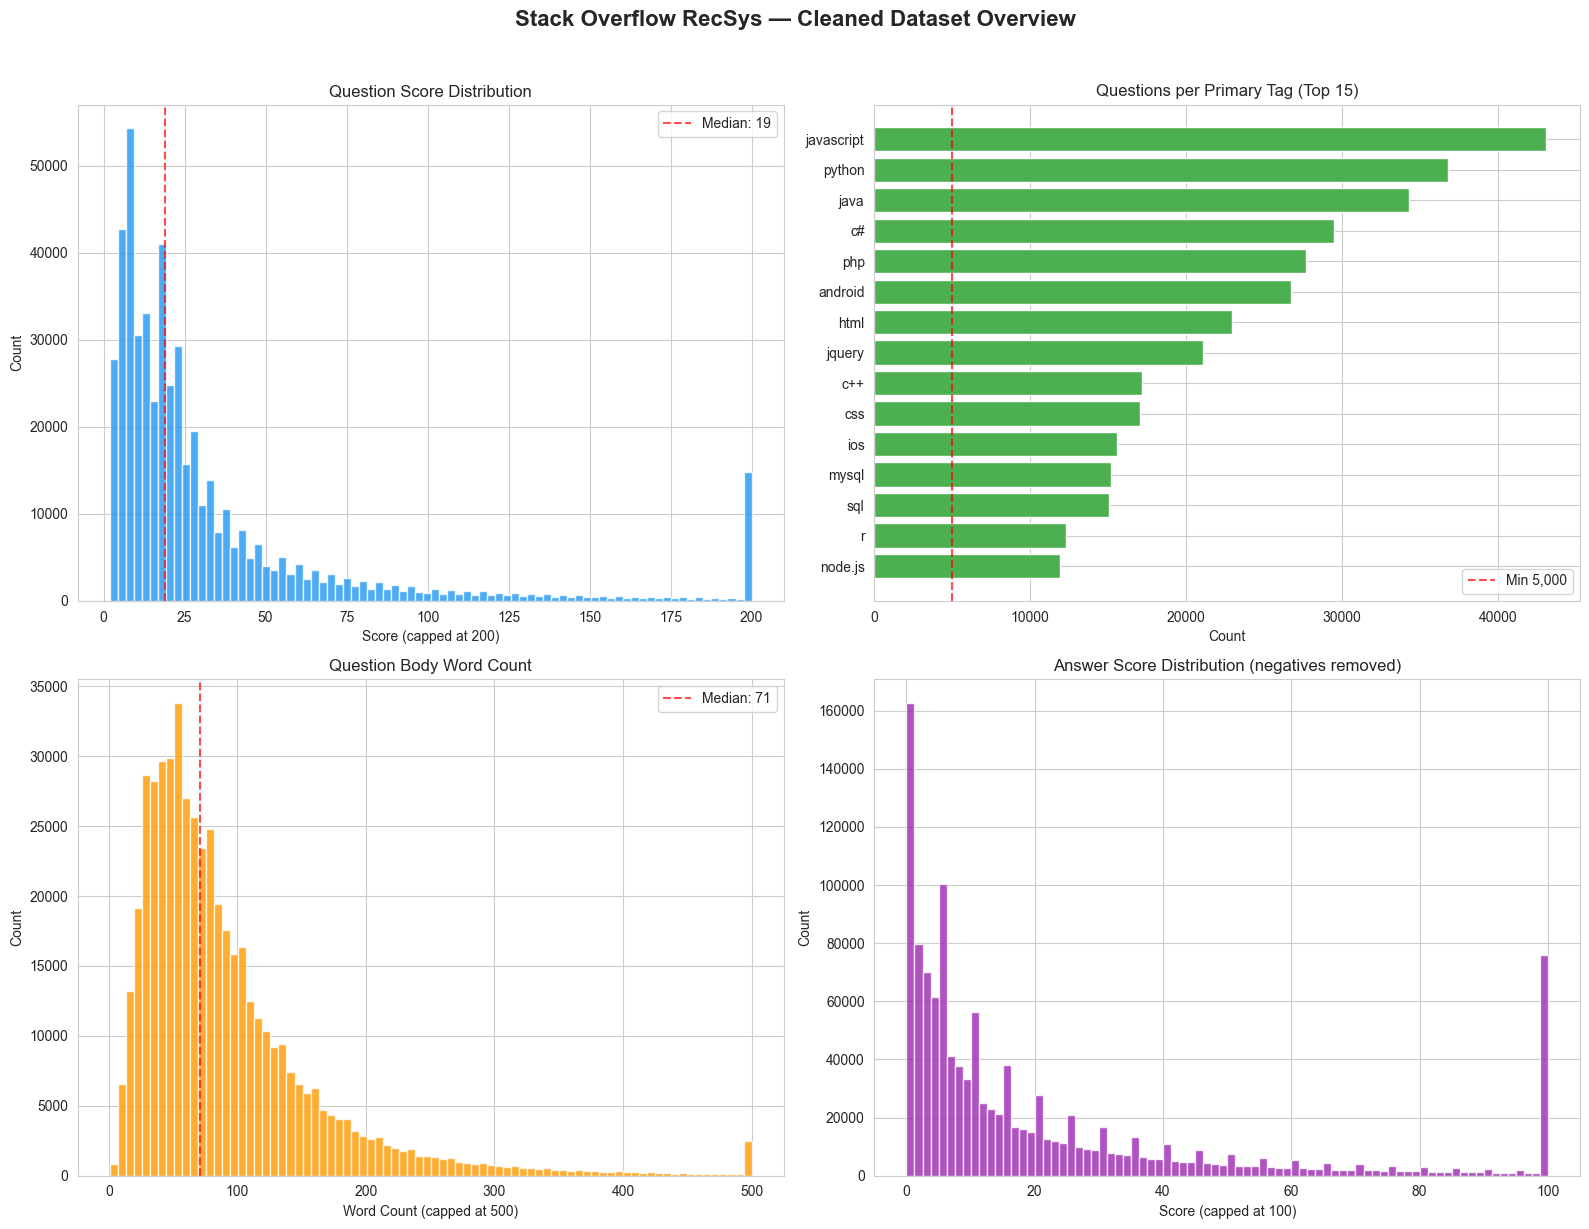

 Saved eda_overview.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

# ============================================================
# Figure 1: Dataset Overview (4 plots)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stack Overflow RecSys — Cleaned Dataset Overview', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Question score distribution
axes[0, 0].hist(questions_clean['score'].clip(upper=200), bins=80, 
                color='#2196F3', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Question Score Distribution', fontsize=12)
axes[0, 0].set_xlabel('Score (capped at 200)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(x=questions_clean['score'].median(), color='red', 
                     linestyle='--', alpha=0.7, label=f'Median: {questions_clean["score"].median():.0f}')
axes[0, 0].legend()

# 2. Tag distribution (stratified)
tag_counts = questions_clean['primary_tag'].value_counts().head(15)
axes[0, 1].barh(tag_counts.index[::-1], tag_counts.values[::-1], color='#4CAF50')
axes[0, 1].axvline(x=5000, color='red', linestyle='--', alpha=0.7, label='Min 5,000')
axes[0, 1].set_title('Questions per Primary Tag (Top 15)', fontsize=12)
axes[0, 1].set_xlabel('Count')
axes[0, 1].legend()

# 3. Body word count distribution
axes[1, 0].hist(questions_clean['body_word_count'].clip(upper=500), bins=80, 
                color='#FF9800', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Question Body Word Count', fontsize=12)
axes[1, 0].set_xlabel('Word Count (capped at 500)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].axvline(x=questions_clean['body_word_count'].median(), color='red',
                     linestyle='--', alpha=0.7, label=f'Median: {questions_clean["body_word_count"].median():.0f}')
axes[1, 0].legend()

# 4. Answer score distribution (after removing negatives)
axes[1, 1].hist(answers_clean['score'].clip(upper=100), bins=80,
                color='#9C27B0', edgecolor='white', alpha=0.8)
axes[1, 1].set_title('Answer Score Distribution (negatives removed)', fontsize=12)
axes[1, 1].set_xlabel('Score (capped at 100)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Saved eda_overview.png')

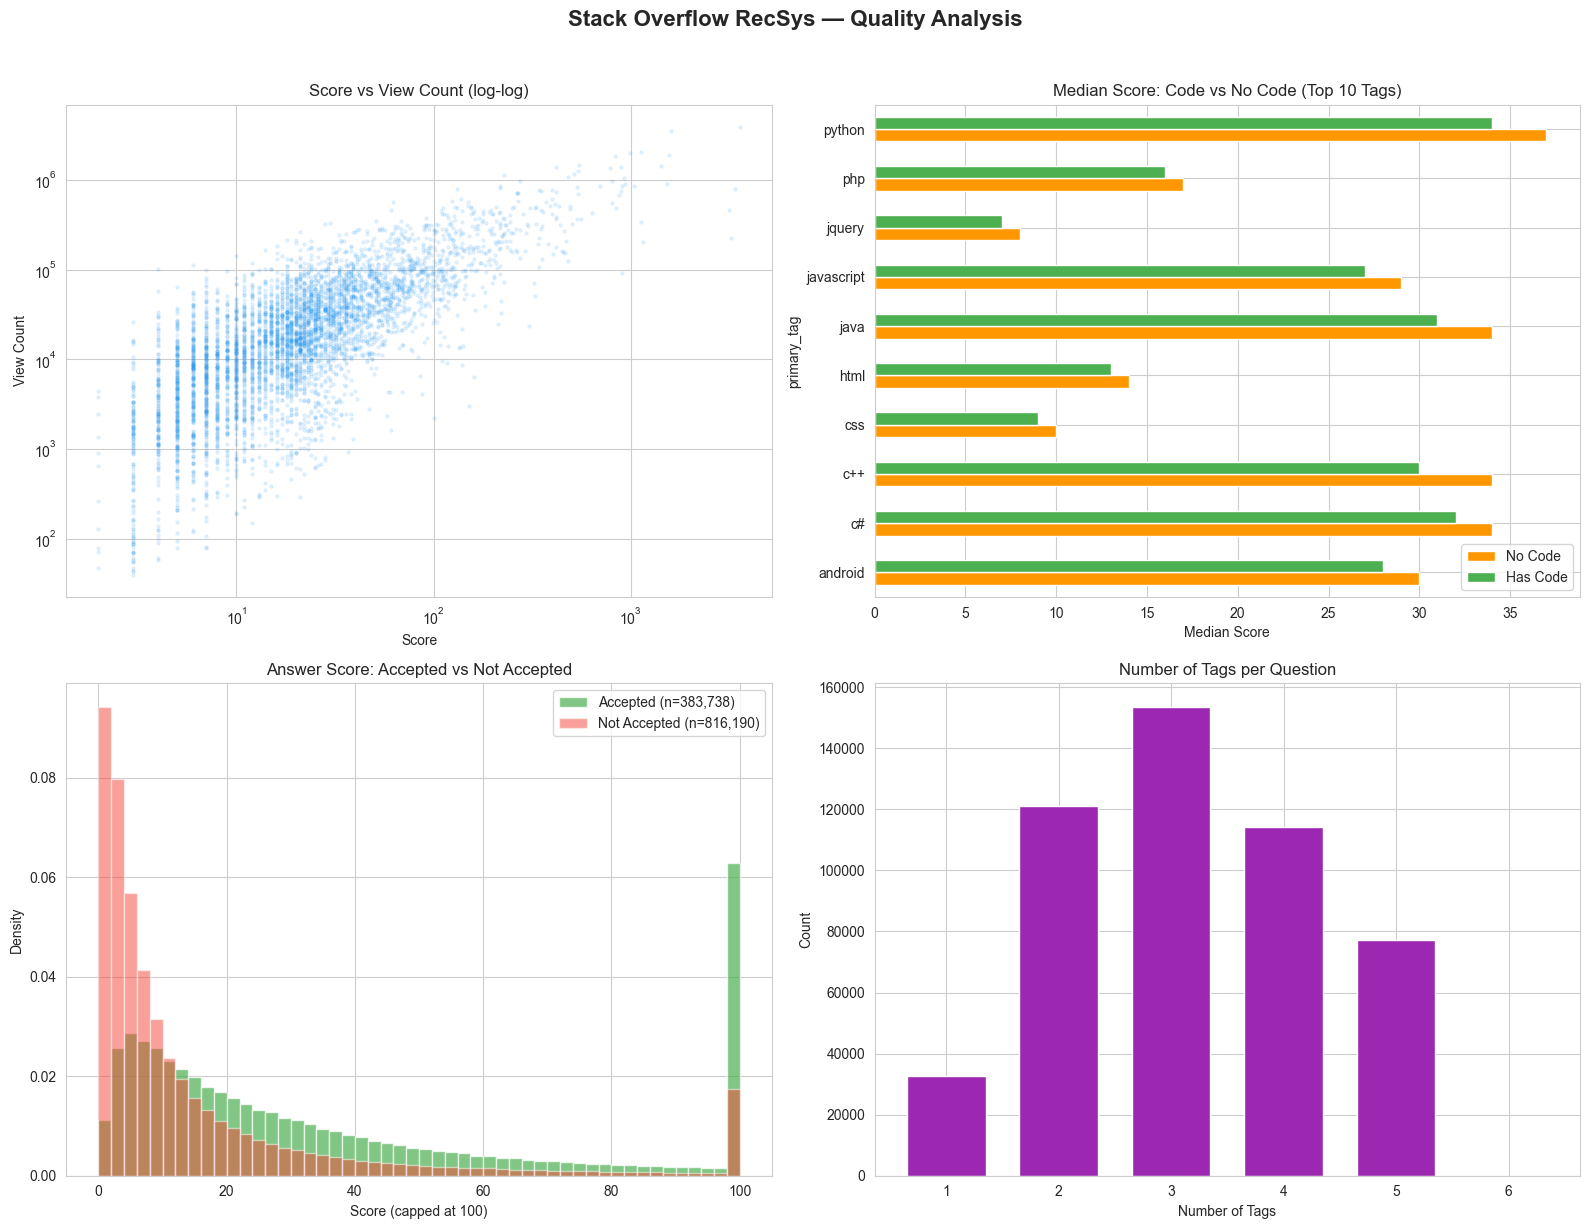

 Saved eda_quality.png


In [20]:
# ============================================================
# Figure 2: Quality Analysis (4 plots)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Stack Overflow RecSys — Quality Analysis', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Score vs View Count (log scale)
sample_scatter = questions_clean.sample(min(5000, len(questions_clean)), random_state=42)
axes[0, 0].scatter(sample_scatter['score'], sample_scatter['view_count'], 
                    alpha=0.1, s=5, color='#2196F3')
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Score vs View Count (log-log)', fontsize=12)
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('View Count')

# 2. Has Code vs Score (by tag)
code_scores = questions_clean.groupby(['primary_tag', 'has_code'])['score'].median().unstack()
top10_tags = questions_clean['primary_tag'].value_counts().head(10).index
code_scores_top10 = code_scores.loc[code_scores.index.isin(top10_tags)]
code_scores_top10.plot(kind='barh', ax=axes[0, 1], color=['#FF9800', '#4CAF50'])
axes[0, 1].set_title('Median Score: Code vs No Code (Top 10 Tags)', fontsize=12)
axes[0, 1].set_xlabel('Median Score')
axes[0, 1].legend(['No Code', 'Has Code'])

# 3. Accepted vs Non-accepted answer scores
accepted_scores = answers_clean[answers_clean['is_accepted']]['score']
non_accepted_scores = answers_clean[~answers_clean['is_accepted']]['score']
axes[1, 0].hist(accepted_scores.clip(upper=100), bins=50, alpha=0.7, 
                color='#4CAF50', label=f'Accepted (n={len(accepted_scores):,})', density=True)
axes[1, 0].hist(non_accepted_scores.clip(upper=100), bins=50, alpha=0.5, 
                color='#F44336', label=f'Not Accepted (n={len(non_accepted_scores):,})', density=True)
axes[1, 0].set_title('Answer Score: Accepted vs Not Accepted', fontsize=12)
axes[1, 0].set_xlabel('Score (capped at 100)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()

# 4. Tags per question distribution
axes[1, 1].hist(questions_clean['num_tags'], bins=range(1, 8), 
                color='#9C27B0', edgecolor='white', rwidth=0.7, align='left')
axes[1, 1].set_title('Number of Tags per Question', fontsize=12)
axes[1, 1].set_xlabel('Number of Tags')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticks(range(1, 7))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_quality.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Saved eda_quality.png')

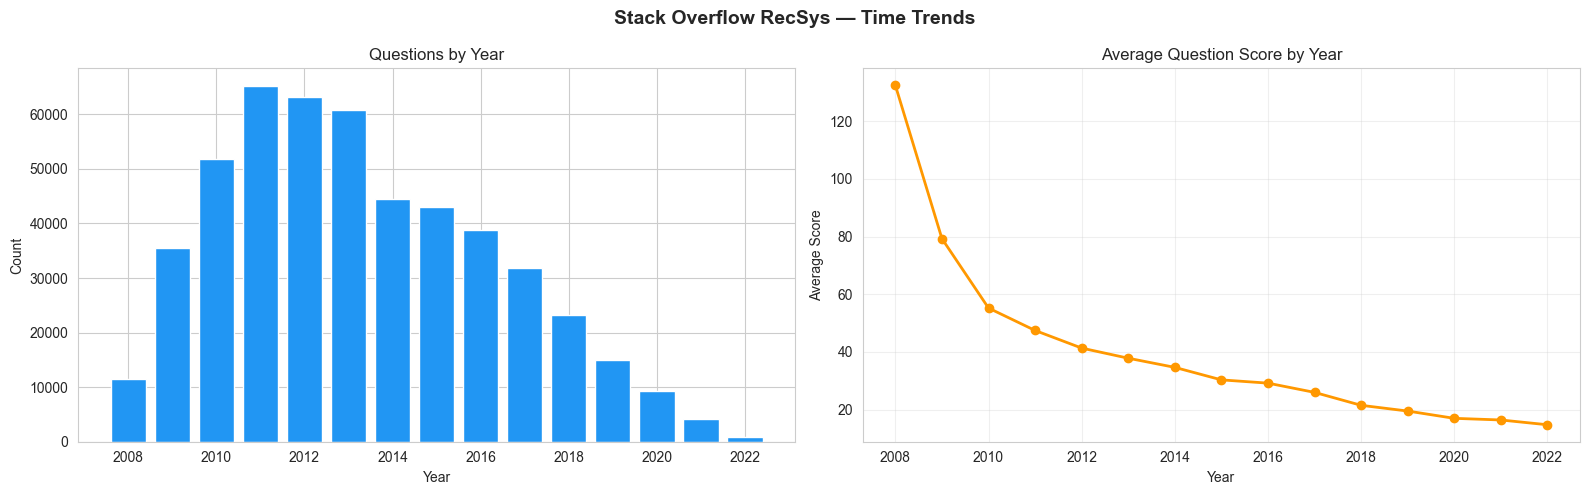

 Saved eda_time_trends.png


In [21]:
# ============================================================
# Figure 3: Time Trends
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Stack Overflow RecSys — Time Trends', 
             fontsize=14, fontweight='bold')

# Questions over time (by year)
questions_clean['year'] = pd.to_datetime(questions_clean['creation_date']).dt.year
yearly = questions_clean.groupby('year').size()
axes[0].bar(yearly.index, yearly.values, color='#2196F3', edgecolor='white')
axes[0].set_title('Questions by Year', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

# Average score by year
yearly_score = questions_clean.groupby('year')['score'].mean()
axes[1].plot(yearly_score.index, yearly_score.values, 'o-', 
             color='#FF9800', linewidth=2, markersize=6)
axes[1].set_title('Average Question Score by Year', fontsize=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Score')
axes[1].grid(True, alpha=0.3)

# Clean up
questions_clean = questions_clean.drop(columns=['year'])

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_time_trends.png'), dpi=150, bbox_inches='tight')
plt.show()
print(' Saved eda_time_trends.png')

In [22]:
print('FINAL CLEANED DATASET REPORT')


print(f'\n QUESTIONS')
print(f'   Rows:              {len(questions_clean):>12,}')
print(f'   Score range:       {questions_clean["score"].min():>12,} to {questions_clean["score"].max():,}')
print(f'   Avg score:         {questions_clean["score"].mean():>12,.1f}')
print(f'   Median score:      {questions_clean["score"].median():>12,.0f}')
print(f'   Avg body words:    {questions_clean["body_word_count"].mean():>12,.0f}')
print(f'   Has code:          {questions_clean["has_code"].mean()*100:>11.1f}%')
print(f'   Has accepted ans:  {questions_clean["has_accepted_answer"].mean()*100:>11.1f}%')
print(f'   Primary tags:      {questions_clean["primary_tag"].nunique():>12}')

print(f'\n ANSWERS')
print(f'   Rows:              {len(answers_clean):>12,}')
print(f'   Score range:       {answers_clean["score"].min():>12,} to {answers_clean["score"].max():,}')
print(f'   Avg score:         {answers_clean["score"].mean():>12,.1f}')
print(f'   Is accepted:       {answers_clean["is_accepted"].mean()*100:>11.1f}%')
print(f'   Avg body words:    {answers_clean["body_word_count"].mean():>12,.0f}')
print(f'   Has code:          {answers_clean["has_code"].mean()*100:>11.1f}%')

questions_with_answers = answers_clean['question_id'].nunique()
print(f'\n LINKAGE')
print(f'   Questions with answers: {questions_with_answers:>10,} / {len(questions_clean):,}')
print(f'   Avg answers/question:   {len(answers_clean)/questions_with_answers:>10.2f}')

print(f'\n COLUMNS')
print(f'   Questions: {list(questions_clean.columns)}')
print(f'   Answers:   {list(answers_clean.columns)}')

FINAL CLEANED DATASET REPORT

 QUESTIONS
   Rows:                   498,643
   Score range:                  2 to 26,621
   Avg score:                 42.2
   Median score:                19
   Avg body words:              93
   Has code:                 66.9%
   Has accepted ans:         79.0%
   Primary tags:                30

 ANSWERS
   Rows:                 1,199,928
   Score range:                  0 to 34,269
   Avg score:                 32.7
   Is accepted:              32.0%
   Avg body words:              78
   Has code:                 66.4%

 LINKAGE
   Questions with answers:    498,643 / 498,643
   Avg answers/question:         2.41

 COLUMNS
   Questions: ['id', 'title', 'body', 'code_blocks', 'tags', 'primary_tag', 'score', 'view_count', 'answer_count', 'has_accepted_answer', 'creation_date', 'title_length', 'body_length', 'body_word_count', 'has_code', 'num_tags']
   Answers:   ['id', 'question_id', 'body', 'code_blocks', 'score', 'answer_rank', 'is_accepted', 'creat